# Análisis Exploratorio de Datos (EDA) - Productividad en teletrabajo

**Objetivo:**  
Examinar los datos de empleados, entender su estructura, calidad, distribuciones y relaciones para preparar el terreno para el modelado.

**Pasos que se seguirán en este notebook:**

1. Cargar el dataset y verificar su estructura (columnas, tipos, valores nulos, duplicados).
2. Obtener estadísticas descriptivas de las variables numéricas.
3. Visualizar la distribución de la variable objetivo (`productividad`) y de las predictoras numéricas.
4. Detectar posibles outliers y variables con sesgo.
5. Analizar las variables categóricas (frecuencias, relación con productividad).
6. Explorar relaciones bivariantes (correlaciones entre numéricas, boxplots por categorías).
7. Documentar hallazgos preliminares que guiarán la limpieza y transformación posterior.

**Nota:** Este notebook solo explora y visualiza; las transformaciones (logaritmos, codificación, escalado) se harán en el siguiente notebook de ETL.

In [2]:
# Importar librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo de graficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Cargar datos
df = pd.read_csv('../data/raw/productividad_empleados.csv')

# Verificar carga
print("Datos cargados correctamente")
print(f"Shape: {df.shape}")
df.head()

Datos cargados correctamente
Shape: (2500, 12)


,productividad,edad,sexo,hijos,años_empresa,satisfaccion_equipo,horas_formacion_mes,distancia_oficina_km,departamento,estres_reportado,bono_anual,jornada_continua
0,26,60,Mujer,No,17,4,4.1,24.1,IT,5,4.8,No
1,25,50,Hombre,No,1,3,7.8,2.1,Marketing,2,6.3,No
2,21,36,Mujer,Sí,29,2,12.1,2.6,Operaciones,2,3.2,No
3,29,64,Hombre,No,1,7,12.3,0.9,Marketing,1,2.9,No
4,29,29,Hombre,Sí,9,9,5.9,1.1,RRHH,3,3.0,No


In [3]:
# Informacion general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   productividad         2500 non-null   int64  
 1   edad                  2500 non-null   int64  
 2   sexo                  2500 non-null   object 
 3   hijos                 2500 non-null   object 
 4   años_empresa          2500 non-null   int64  
 5   satisfaccion_equipo   2500 non-null   int64  
 6   horas_formacion_mes   2500 non-null   float64
 7   distancia_oficina_km  2500 non-null   float64
 8   departamento          2500 non-null   object 
 9   estres_reportado      2500 non-null   int64  
 10  bono_anual            2500 non-null   float64
 11  jornada_continua      2500 non-null   object 
dtypes: float64(3), int64(5), object(4)
memory usage: 234.5+ KB


## Calidad de los datos

- **No hay valores nulos** en ninguna de las 12 columnas (2500 registros completos).
- Los tipos de datos son correctos:
  - Numéricas: `int64` y `float64` (8 columnas)
  - Categóricas: `object` (4 columnas: sexo, hijos, departamento, jornada_continua)
- **Memoria utilizada:** 234.5 KB (dataset pequeño y manejable).

No se requiere limpieza por valores faltantes.

In [4]:
df.describe()

,productividad,edad,años_empresa,satisfaccion_equipo,horas_formacion_mes,distancia_oficina_km,estres_reportado,bono_anual
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000
mean,25.606400,43.524400,15.198800,5.564000,7.95904,4.989280,5.405200,3.967120
std,4.673437,12.633877,8.980843,2.847375,7.35562,5.048433,2.832988,2.711315
min,15.000000,22.000000,0.000000,1.000000,0.00000,0.000000,1.000000,0.100000
25%,22.000000,33.000000,8.000000,3.000000,2.30000,1.400000,3.000000,2.000000
50%,26.000000,44.000000,15.000000,6.000000,5.60000,3.400000,5.000000,3.400000
75%,29.000000,54.000000,23.000000,8.000000,11.50000,7.100000,8.000000,5.400000
max,42.000000,65.000000,30.000000,10.000000,30.00000,42.700000,10.000000,15.000000


## Interpretación de estadísticas descriptivas

**Variable objetivo (`productividad`):**
- Rango: 15-42 tareas/semana.
- Media (25.6) y mediana (26) casi iguales → distribución **simétrica**, sin sesgo fuerte.
- No se observan valores atípicos evidentes.

**Variables con sesgo positivo (media > mediana):**
- `horas_formacion_mes`: media (7.96) vs mediana (5.6)
- `distancia_oficina_km`: media (4.99) vs mediana (3.4)
- `bono_anual`: media (3.97) vs mediana (3.4)

Estas variables tienen cola larga hacia la derecha (pocos casos con valores altos).

**Variables simétricas (media ≈ mediana):**
- `edad`, `años_empresa`, `estres_reportado`, `productividad`

**Variables con sesgo negativo leve:**
- `satisfaccion_equipo`: media (5.56) vs mediana (6) → ligeramente desplazada a la izquierda (no preocupa).

**Outliers potenciales (valores máximos alejados del percentil 75):**
- `horas_formacion_mes` (máx 30 vs Q3=11.5)
- `distancia_oficina_km` (máx 42.7 vs Q3=7.1)
- `bono_anual` (máx 15 vs Q3=5.4)

Se confirmará visualmente con boxplots.

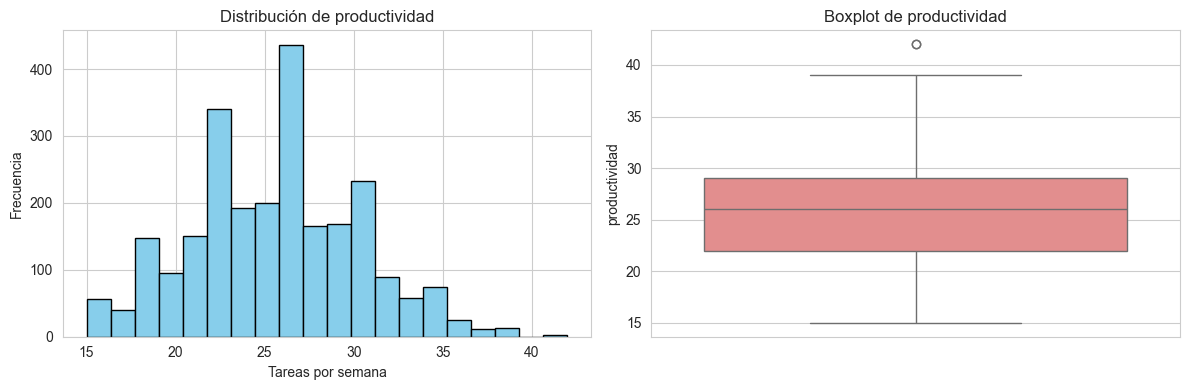

In [5]:
# Visalización de la variable objetivo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(df['productividad'], bins=20, edgecolor='black', color='skyblue')
axes[0].set_title('Distribución de productividad')
axes[0].set_xlabel('Tareas por semana')
axes[0].set_ylabel('Frecuencia')

# Boxplot
sns.boxplot(ax=axes[1], y=df['productividad'], color='lightcoral')
axes[1].set_title('Boxplot de productividad')

plt.tight_layout()
plt.show()

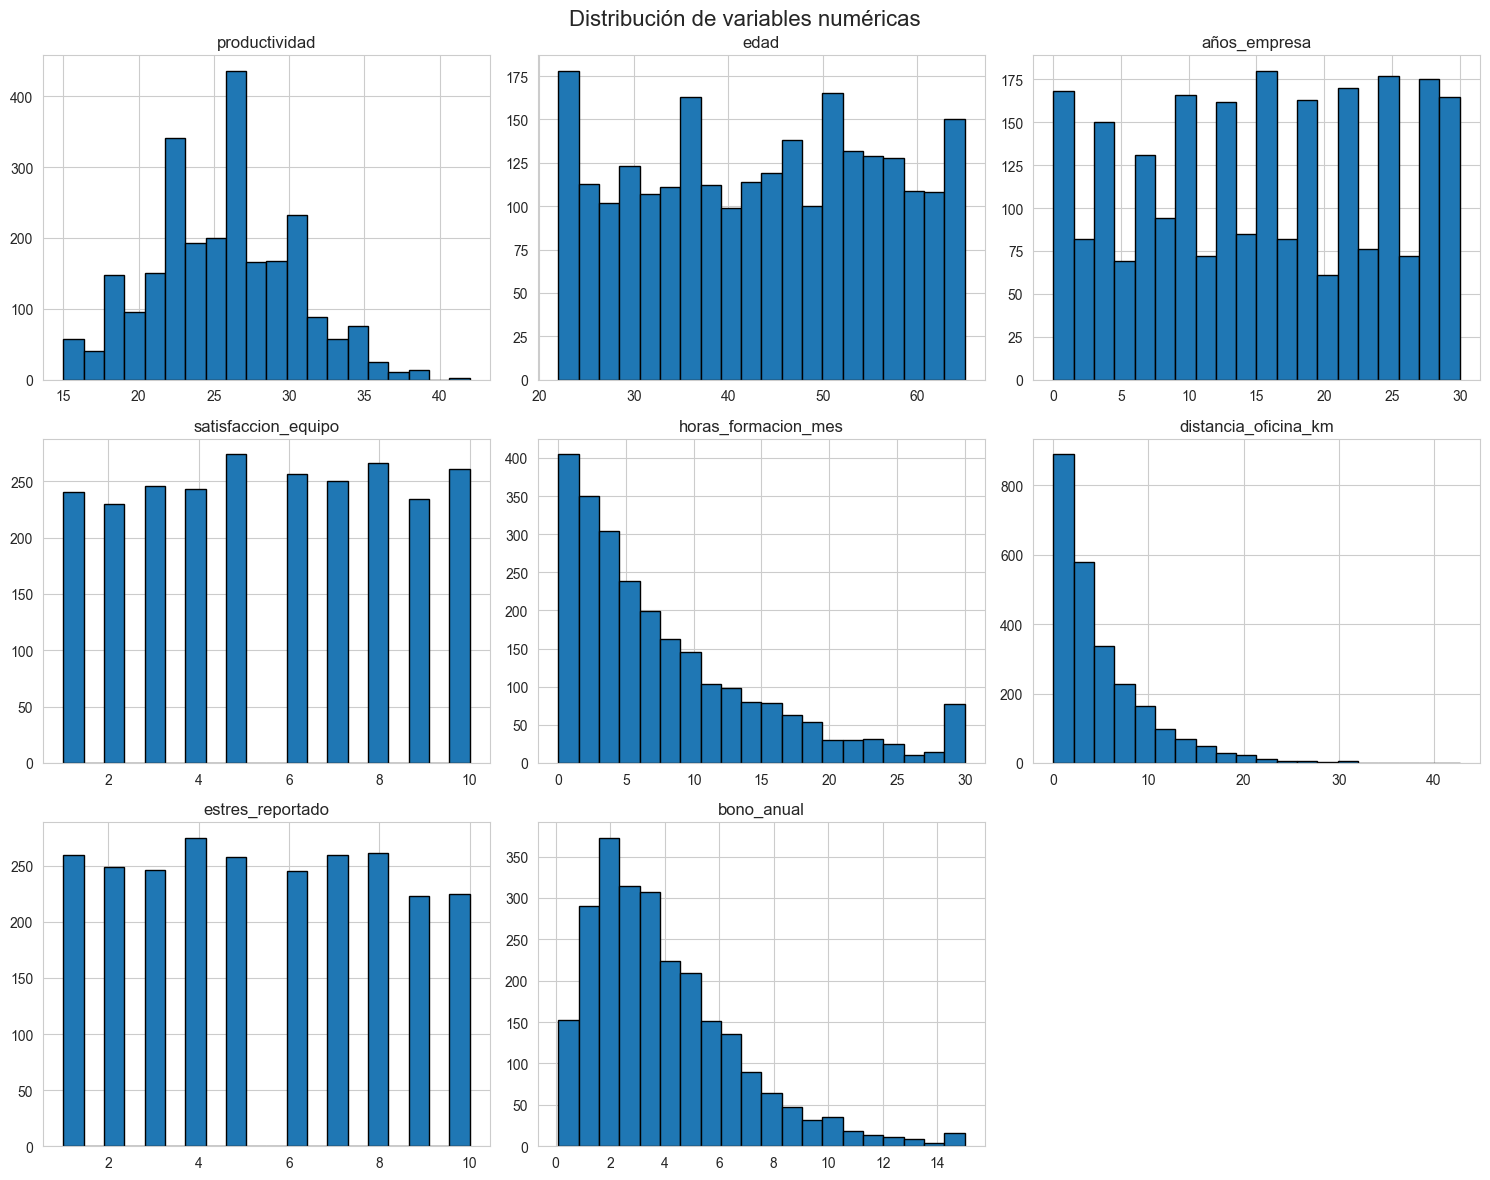

In [6]:
# Seleccionar solo columnas numéricas (int64 y float64)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Grid de histogramas
df[num_cols].hist(bins=20, figsize=(15, 12), edgecolor='black')
plt.suptitle('Distribución de variables numéricas', fontsize=16)
plt.tight_layout()
plt.show()

## Distribución de variables predictoras numéricas

**Variables con distribución normal o uniforme (sin sesgo relevante):**
- `edad`, `años_empresa`, `satisfaccion_equipo`, `estres_reportado`: presentan una distribución uniforme o simétrica, sin picos extremos ni sesgo aparente. **No requieren transformación.**

**Variables con sesgo positivo (cola larga hacia la derecha):**
- `horas_formacion_mes`
- `distancia_oficina_km`
- `bono_anual`

Estas tres variables concentran la mayoría de los valores en el extremo izquierdo (bajas horas de formación, poca distancia, bonos bajos) y tienen una cola larga hacia la derecha, con algunos valores extremadamente altos. **Se aplicará transformación logarítmica (`log1p`) para reducir el sesgo y mejorar el rendimiento de modelos lineales.**

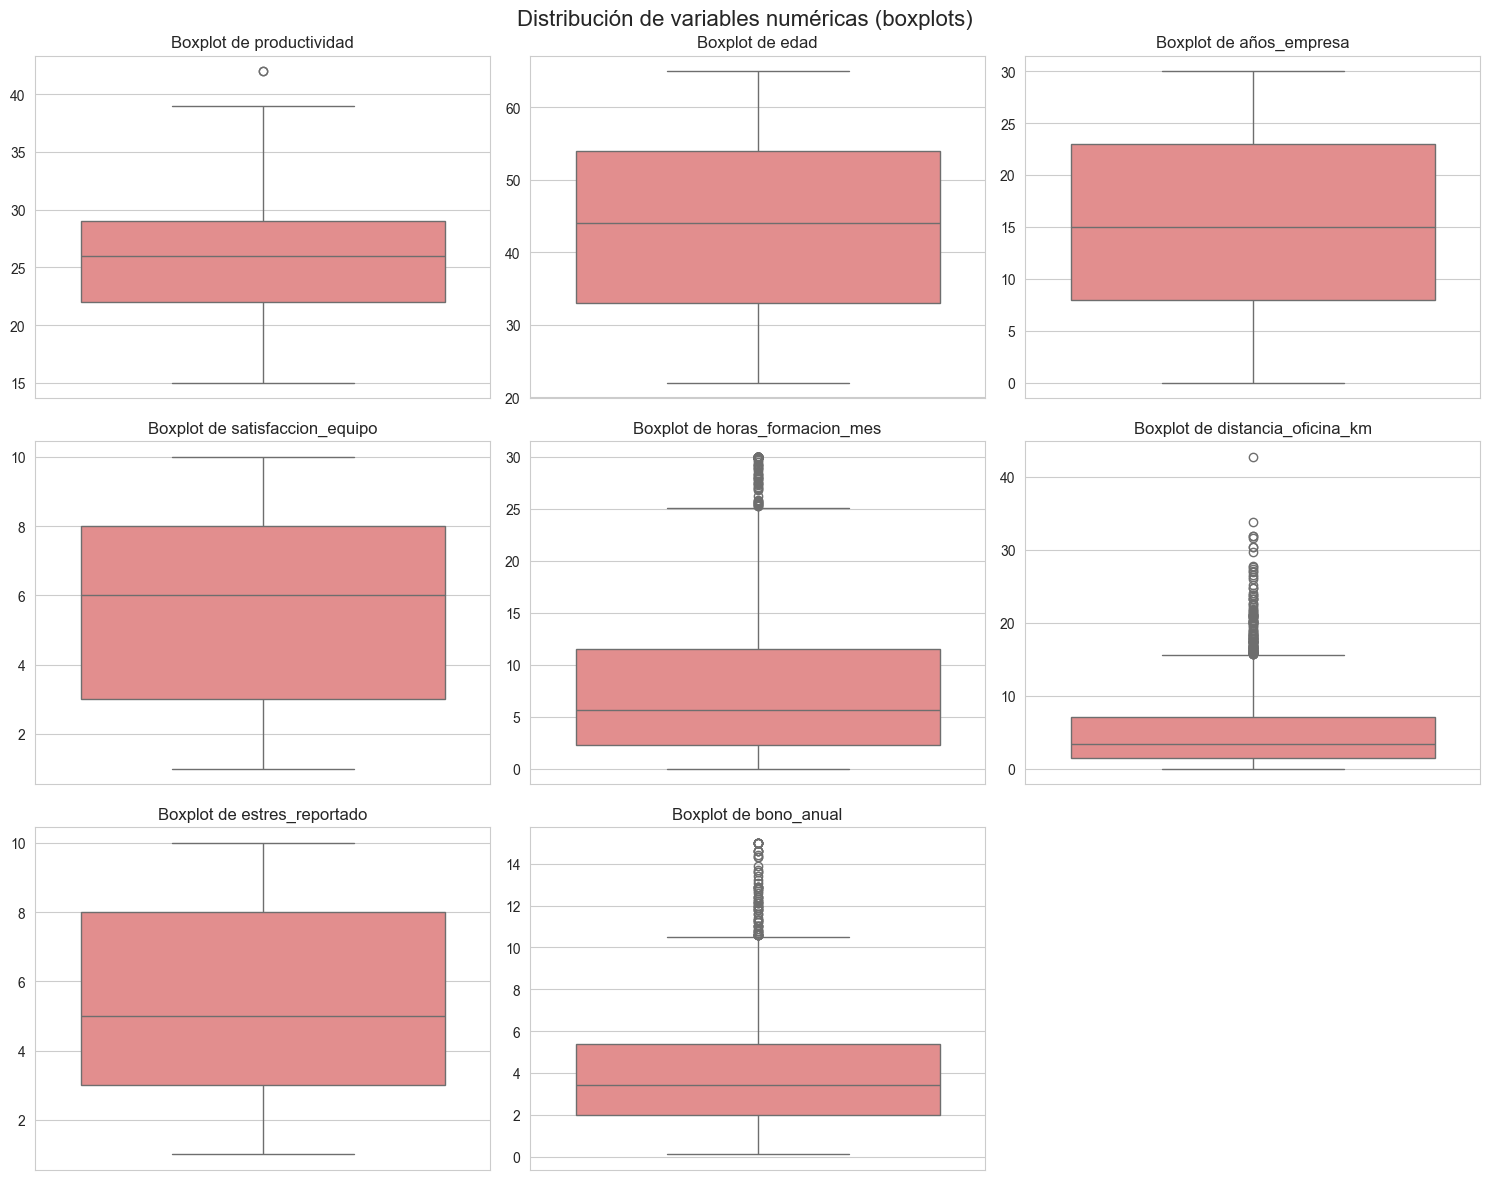

In [7]:
# Boxplots de todas las numéricas en grid
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
n_cols = len(num_cols)

# Calcular filas necesarias (3 columnas por fila)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(ax=axes[i], y=df[col], color='lightcoral')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('')

# Ocultar ejes sobrantes si los hay
for i in range(len(num_cols), len(axes)):
    axes[i].axis('off')

plt.suptitle('Distribución de variables numéricas (boxplots)', fontsize=16)
plt.tight_layout()
plt.show()

## Detección de outliers (boxplots)

**Variables sin outliers:**
- `edad`, `años_empresa`, `satisfaccion_equipo`, `estres_reportado`: no presentan valores fuera de los bigotes.

**Variable objetivo:**
- `productividad`: presenta un único outlier en el extremo superior. Al ser un caso real y no un error de datos, se mantiene sin transformación.

**Variables con múltiples outliers superiores (casos reales, no errores):**
- `horas_formacion_mes`: varios outliers por encima del bigote superior (empleados con muchas horas de formación).
- `distancia_oficina_km`: varios outliers por encima (empleados que viven muy lejos de la oficina).
- `bono_anual`: varios outliers por encima (empleados con bonos excepcionalmente altos).

**Decisión:** No se eliminan outliers porque representan casos reales. La transformación logarítmica (`log1p`) ayudará a reducir su influencia en modelos lineales, mientras que los modelos basados en árboles los manejarán de forma natural.

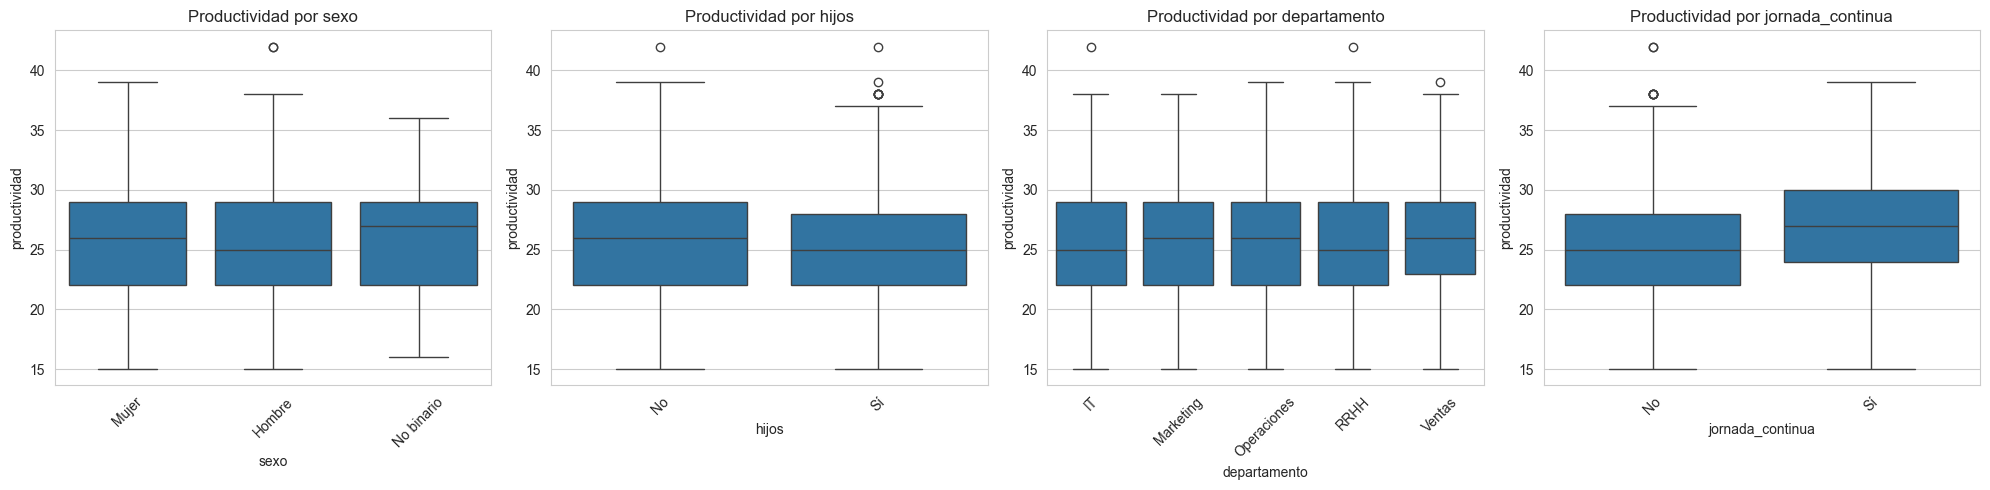


Media de productividad por sexo:
sexo
Hombre        25.555368
Mujer         25.623462
No binario    26.010204
Name: productividad, dtype: float64

Media de productividad por hijos:
hijos
Sí    25.354455
No    25.777181
Name: productividad, dtype: float64

Media de productividad por departamento:
departamento
RRHH           25.351779
IT             25.484677
Marketing      25.592405
Ventas         25.750847
Operaciones    25.847769
Name: productividad, dtype: float64

Media de productividad por jornada_continua:
jornada_continua
No    25.182022
Sí    26.655556
Name: productividad, dtype: float64


In [8]:
# Seleccionar columnas categóricas (tipo object)
cat_cols = df.select_dtypes(include=['object']).columns

# Grid de boxplots de productividad por categoría
n_cols = len(cat_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 5))
if n_cols == 1:
    axes = [axes]
for i, col in enumerate(cat_cols):
    sns.boxplot(ax=axes[i], data=df, x=col, y='productividad')
    axes[i].set_title(f'Productividad por {col}')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Mostrar medias de productividad por categoría
for col in cat_cols:
    print(f"\nMedia de productividad por {col}:")
    print(df.groupby(col)['productividad'].mean().sort_values())

### Medias de productividad por categoría

- **sexo**: diferencias mínimas (≈0.4 puntos entre categorías). No influye.
- **hijos**: quienes no tienen hijos presentan productividad ligeramente superior (25.78 vs 25.35). Diferencia pequeña.
- **departamento**: las medias son muy similares (25.35-25.85). El departamento no parece relevante.
- **jornada_continua**: diferencia clara (26.66 vs 25.18, ≈1.5 puntos). Es la categórica más importante.

**Conclusión:** `jornada_continua` será muy útil para el modelo. Las otras se mantienen pero probablemente tengan baja importancia.

Matriz de correlación (variables numéricas):
                      productividad      edad  años_empresa  \
productividad              1.000000  0.145591      0.073276   
edad                       0.145591  1.000000      0.008649   
años_empresa               0.073276  0.008649      1.000000   
satisfaccion_equipo        0.515061  0.038250     -0.008330   
horas_formacion_mes        0.479615 -0.016907      0.022204   
distancia_oficina_km      -0.028315  0.009253      0.011002   
estres_reportado          -0.341963  0.033136      0.005436   
bono_anual                 0.022948  0.029550      0.050919   

                      satisfaccion_equipo  horas_formacion_mes  \
productividad                    0.515061             0.479615   
edad                             0.038250            -0.016907   
años_empresa                    -0.008330             0.022204   
satisfaccion_equipo              1.000000             0.016702   
horas_formacion_mes              0.016702             1.0

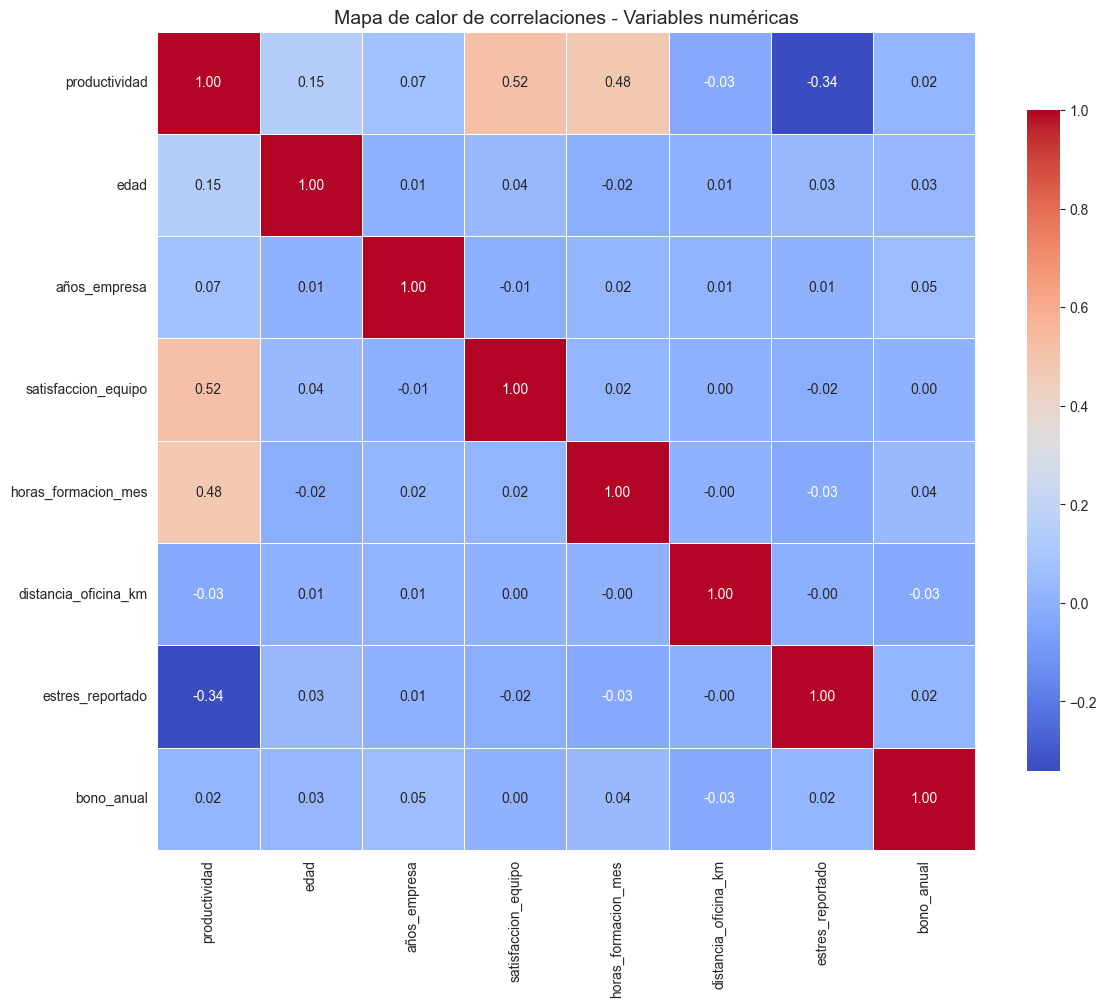

In [9]:
# Seleccionar solo las columnas numéricas
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calcular la matriz de correlación
corr_matrix = df[num_cols].corr()

# Mostrar la matriz de correlación en forma de tabla (opcional)
print("Matriz de correlación (variables numéricas):")
print(corr_matrix)

# Heatmap (mapa de calor) de la matriz de correlación
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Mapa de calor de correlaciones - Variables numéricas', fontsize=14)
plt.tight_layout()
plt.show()

## Matriz de correlación entre variables numéricas

**Observaciones:**

- **No se detecta multicolinealidad** (correlaciones altas entre predictoras). Todos los pares de variables predictoras tienen correlaciones muy cercanas a cero (por ejemplo, `edad` con `años_empresa`: 0.0086; `satisfaccion_equipo` con `horas_formacion_mes`: 0.0167; `estres_reportado` con cualquier otra: valores < 0.04). Por tanto, no hay redundancia entre las variables numéricas y se pueden incluir todas en los modelos sin problemas de inestabilidad.

- **Relaciones con la variable objetivo (`productividad`):**
  - `satisfaccion_equipo` (0.515) y `horas_formacion_mes` (0.480) presentan correlación positiva moderada. Son las variables numéricas con mayor relación lineal directa con la productividad.
  - `estres_reportado` (-0.342) muestra correlación negativa débil a moderada: a mayor estrés, menor productividad.
  - El resto de variables numéricas (`edad`, `años_empresa`, `distancia_oficina_km`, `bono_anual`) tienen correlaciones muy débiles con la productividad (|r| < 0.15). Esto sugiere que, de forma lineal, su influencia es limitada; no obstante, podrían tener relaciones no lineales que los modelos de árboles podrían capturar.

**Conclusión:** No hay multicolinealidad. Las variables más prometedoras para predecir productividad son `satisfaccion_equipo` y `horas_formacion_mes`. El resto se mantienen por posible valor en interacciones o no linealidades.

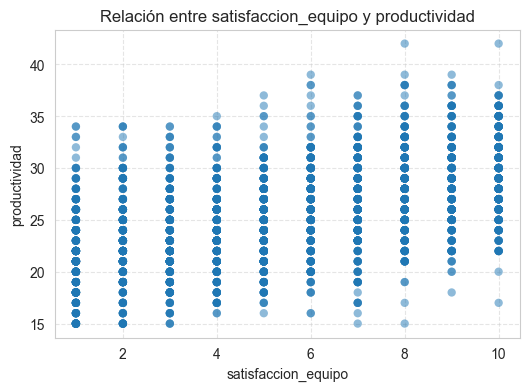

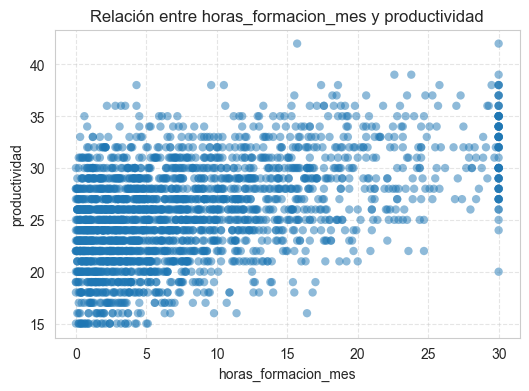

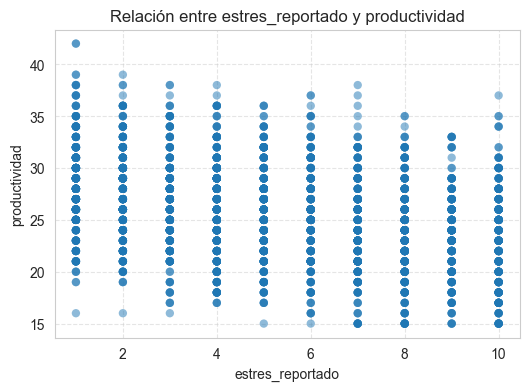

In [12]:
# Diagramas de dispersión (scatter plots) de las variables numéricas
# que tienen mayor correlación con la variable objetivo (productividad)

# Lista de las variables seleccionadas según la matriz de correlación
top_vars = ['satisfaccion_equipo', 'horas_formacion_mes', 'estres_reportado']

for var in top_vars:
    plt.figure(figsize=(6,4))
    plt.scatter(df[var], df['productividad'], alpha=0.5, edgecolors='none')
    plt.xlabel(var)
    plt.ylabel('productividad')
    plt.title(f'Relación entre {var} y productividad')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

### Diagramas de dispersión (variables numéricas vs. productividad)

**`satisfaccion_equipo`:**
- Se observa una tendencia ascendente, aunque muy ligera: a mayor satisfacción con el equipo, la productividad tiende a ser ligeramente más alta.
- La dispersión vertical es pequeña; los puntos se concentran en rangos relativamente estrechos para cada nivel de satisfacción.
- No se aprecian relaciones no lineales ni outliers extremos.

**`horas_formacion_mes`:**
- Es la variable que muestra un cambio más notable. A medida que aumentan las horas de formación, la productividad tiende a subir de forma más clara que en las otras variables.
- Se aprecia una nube de puntos con tendencia ascendente; los empleados con más de 20 horas mensuales suelen tener productividades más altas (por encima de 28‑30 tareas).
- La dispersión es moderada, pero la tendencia general es evidente.

**`estres_reportado`:**
- Se aprecia una tendencia descendente, también ligera: a mayor estrés, la productividad tiende a disminuir.
- La variabilidad es baja; los puntos se agrupan en bandas verticales estrechas para cada nivel de estrés.
- No se detectan formas curvas ni valores atípicos que distorsionen la relación.

**Conclusión:** Los diagramas de dispersión confirman los coeficientes de correlación obtenidos. `horas_formacion_mes` es la variable numérica con mayor impacto visual en la productividad, seguida por `satisfaccion_equipo` y `estres_reportado`. Las relaciones son aproximadamente lineales, por lo que las correlaciones de Pearson son representativas.

# Conclusiones del Análisis Exploratorio de Datos (EDA)

## 1. Calidad de los datos
- No hay valores nulos en ninguna columna (2500 registros completos).
- No hay filas duplicadas.
- Tipos de datos correctos: numéricas (`int64`, `float64`) y categóricas (`object`).

## 2. Variable objetivo: `productividad`
- Rango: 15‑42 tareas/semana.
- Distribución aproximadamente normal (media ≈ mediana).
- Un único outlier en el extremo superior (caso real, no se elimina).

## 3. Variables numéricas
- **Sin sesgo fuerte**: `edad`, `años_empresa`, `satisfaccion_equipo`, `estres_reportado`.
- **Sesgo positivo (cola a la derecha)**: `horas_formacion_mes`, `distancia_oficina_km`, `bono_anual`.  
  Se aplicará transformación logarítmica (`log1p`).
- **Outliers**: presentes en las tres variables con sesgo, pero son casos reales (empleados con mucha formación, lejanía o bonos altos). No se eliminan.
- **Multicolinealidad**: no se detectan correlaciones altas entre predictoras (todas < 0.1). No hay redundancia.

## 4. Variables categóricas
- **`jornada_continua`**: diferencia clara en productividad (≈1.5 puntos). Es la categórica más relevante.
- **`sexo`, `hijos`, `departamento`**: diferencias muy pequeñas (≤0.5 puntos). Probablemente baja contribución, pero se mantienen para evaluación.

## 5. Relaciones con la productividad
- **Correlaciones moderadas**:  
  - `satisfaccion_equipo`: 0.52 (positiva)  
  - `horas_formacion_mes`: 0.48 (positiva)  
  - `estres_reportado`: -0.34 (negativa)
- **Correlaciones débiles** (|r| < 0.15): `edad`, `años_empresa`, `distancia_oficina_km`, `bono_anual`.
- Los diagramas de dispersión confirman las tendencias lineales.

## 6. Próximos pasos (ETL y modelado)
- **Transformaciones**: aplicar `log1p` a `horas_formacion_mes`, `distancia_oficina_km`, `bono_anual`.
- **Codificación**: convertir categóricas a numéricas (one‑hot o binarias).
- **Escalado**: necesario para modelos lineales (opcional para árboles).
- **Modelado**: probar Regresión Lineal, Random Forest, XGBoost. Evaluar con validación cruzada (RMSE, MAE, R²).
- **Selección de características**: si es necesario, usar regularización o eliminar variables con baja importancia.

---
**Resumen ejecutivo**: El dataset está limpio y listo para modelar. Las variables más prometedoras son `jornada_continua`, `satisfaccion_equipo` y `horas_formacion_mes`. Se transformarán las tres con sesgo. Los outliers se mantienen.